# SC-08b - MEV et rendement du fournisseur de liquidite

[<< SC-8 DeFi Primitives](SC-08-DeFi-Primitives-Python.ipynb) | [Sommaire](../README.md) | [SC-9 DAO Governance >>](SC-09-DAO-Governance-Python.ipynb)

Un pool a produit constant ne se contente pas d'echanger : il **paie** ceux qui y deposent
leur capital, et il **subit** ceux qui savent dans quel ordre leurs transactions seront
inclues. Ce carnet chiffre les deux.

Le fil : on reprend le noyau de swap de SC-08 (produit constant `x*y=k` avec frais),
on mesure ce qu'un deposant gagne (frais) et ce qu'il perd (perte non-permanente),
puis on simule les deux extractions canoniques -- le **sandwich** et le **backrun** --
pour repondre a une seule question : **qui paie l'extraction ?**

Tout est **hors chaine**. Aucune chaine locale n'est requise : c'est ce qui rend les
sorties de ce carnet reproductibles telles quelles.

## 0. Le noyau : swap a produit constant

La semantique du swap appartient deja a cette serie : `SC-08-DeFi-Primitives-Python.ipynb`
l'implemente dans sa cellule 4. Un carnet n'etant pas importable, le noyau est repris ici en
**copie pedagogique declaree** -- et cette copie est *verifiee contre la serie source* plutot
que supposee equivalente : SC-08 a commite une sortie chiffree (1000 ETH / 2 000 000 USDC,
swap de 10 ETH a 0,3 %, soit `19743.16 USDC` et `1.96 %` d'impact). La cellule suivante
l'utilise comme **temoin negatif** : si le noyau derive, elle rougit.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np


def simulate_swap(reserve_a, reserve_b, amount_in, fee_percent=0.3):
    """Echange `amount_in` de A contre B dans un pool a produit constant.

    Copie du noyau de SC-08 (cellule 4) : les frais restent dans le pool, donc la
    constante k croit -- c'est exactement ce que touche le fournisseur de liquidite.
    """
    amount_in_with_fee = amount_in * (1 - fee_percent / 100)
    k = reserve_a * reserve_b
    new_reserve_a = reserve_a + amount_in_with_fee
    new_reserve_b = k / new_reserve_a
    amount_out = reserve_b - new_reserve_b
    price_before = reserve_b / reserve_a
    price_after = new_reserve_b / new_reserve_a
    price_impact = (price_before - price_after) / price_before * 100
    return amount_out, new_reserve_a, new_reserve_b, price_impact


def swap_b_vers_a(reserve_a, reserve_b, amount_in_b, fee_percent=0.3):
    """Echange `amount_in_b` de l'actif B contre A, en gardant l'orientation (A, B).

    Le noyau de SC-08 n'accepte que A -> B ; on l'appelle donc retourne, puis on
    remet le resultat dans l'orientation (reserve_a, reserve_b) pour que le reste du
    carnet ne manipule qu'une seule convention.
    """
    amount_out, new_b, new_a, impact = simulate_swap(reserve_b, reserve_a, amount_in_b,
                                                    fee_percent)
    return amount_out, new_a, new_b, impact


# Temoin negatif : la sortie committee de SC-08, reproduite a l'identique.
_out, _ra, _rb, _impact = simulate_swap(1000.0, 2_000_000.0, 10.0)
assert f"{_out:.2f}" == "19743.16", f"noyau divergent de SC-08 : {_out:.2f}"
assert f"{_impact:.2f}" == "1.96", f"impact divergent de SC-08 : {_impact:.2f}"

print(f"Pool de reference : {1000.0:,.0f} A / {2_000_000.0:,.0f} B")
print(f"10 A echanges -> {_out:,.2f} B, impact {_impact:.2f} %")
print(f"Reserves apres  : {_ra:,.2f} A / {_rb:,.2f} B")
print("Temoin SC-08    : 19743.16 B, impact 1.96 % -- identique")

Pool de reference : 1,000 A / 2,000,000 B
10 A echanges -> 19,743.16 B, impact 1.96 %
Reserves apres  : 1,009.97 A / 1,980,256.84 B
Temoin SC-08    : 19743.16 B, impact 1.96 % -- identique


### Lecture du resultat

Le noyau reproduit la sortie de SC-08 au centime : `19743.16 USDC` pour 10 ETH echanges
dans un pool 1000/2 000 000 a 0,3 % de frais, avec un impact de prix de `1.96 %`.

Ce n'est pas un detail de confort : c'est ce qui autorise a parler d'une **meme** semantique
dans deux carnets sans les avoir fusionnes. Le jour ou SC-08 changera de convention de frais,
cette assertion tombera -- au lieu d'un ecart silencieux entre deux series.

## 1. Ce que gagne le fournisseur de liquidite

Deposer dans un pool, c'est preter ses deux actifs a un marcheur. En echange, on touche une
part des frais. La part est proportionnelle a la part de liquidite detenue, et les frais sont
preleves sur **chaque** swap -- donc la recette depend du volume, pas de la direction du prix.

On modelise un deposant qui apporte 10 % du pool et le laisse travailler sur un volume
quotidien donne, pendant un nombre de jours donne, sans mouvement de prix.

In [2]:
def frais_du_deposant(volume_journalier, jours, part_du_pool, fee_percent=0.3):
    """Recette de frais d'un deposant, en pourcentage de son apport initial.

    `volume_journalier` est le volume echange dans le pool, dans l'unite de l'actif B.
    Le deposant empoche `part_du_pool` de ces frais, chaque jour.
    """
    frais_totaux = volume_journalier * jours * fee_percent / 100
    return frais_totaux * part_du_pool


pool_b = 2_000_000.0          # reserve de l'actif B
part = 0.10                   # 10 % du pool
apport = pool_b * part

for volume, jours in ((200_000.0, 1), (200_000.0, 30), (2_000_000.0, 30)):
    gagne = frais_du_deposant(volume, jours, part)
    print(f"volume {volume:>12,.0f}/j sur {jours:>3} j -> {gagne:>10,.2f} B "
          f"({gagne / apport * 100:>5.2f} % de l'apport)")

volume      200,000/j sur   1 j ->      60.00 B ( 0.03 % de l'apport)
volume      200,000/j sur  30 j ->   1,800.00 B ( 0.90 % de l'apport)
volume    2,000,000/j sur  30 j ->  18,000.00 B ( 9.00 % de l'apport)


### Lecture du resultat

Sur 200 000 B de volume quotidien et 30 jours, le deposant encaisse environ 1 800 B, soit
pres de 1 % de son apport -- sans que le prix ait bouge d'un centime. Les frais sont une
**rente de volume** : elle ne demande pas d'avoir raison sur le prix, seulement qu'il se passe
quelque chose.

Retenons le second chiffre : a 2 000 000 B de volume quotidien -- soit un renouvellement
complet du pool chaque jour -- la recette mensuelle approche 10 % de l'apport. C'est l'ordre
de grandeur qu'il faudra opposer a la perte de la section suivante.

## 2. Ce que perd le fournisseur de liquidite : la perte non-permanente

Le pool ne detient jamais les proportions qu'un detenteur aurait gardees : il vend ce qui
monte et achete ce qui baisse. Quand le prix revient a son point de depart, le pool a
exactement la meme valeur qu'au debut -- d'ou le nom *non-permanente*. Le probleme n'est pas
la perte elle-meme, mais le fait qu'elle est **realisee par rapport a simplement garder**.

Pour un ratio de prix `p` (final / initial), la valeur du pool rapportee a celle d'un
detenteur passif vaut `2*sqrt(p)/(1+p) - 1`. On la calcule par la formule **et** par une
simulation directe de l'etat du pool, pour que les deux se controlent.

       p      formule   simulation
    0.50    -5.7191%    -5.7191%
    0.80    -0.6192%    -0.6192%
    1.00     0.0000%     0.0000%
    1.25    -0.6192%    -0.6192%
    2.00    -5.7191%    -5.7191%
    4.00   -20.0000%   -20.0000%


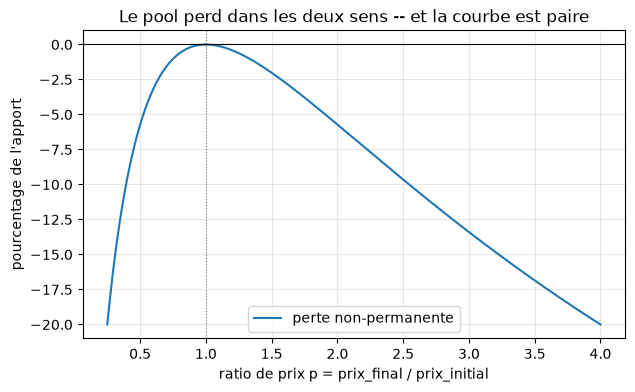

In [3]:
def perte_non_permanente(p):
    """Perte non-permanente pour un ratio de prix p = prix_final / prix_initial.

    Renvoie un nombre negatif : la fraction de valeur perdue par rapport a garder.
    """
    return 2 * math.sqrt(p) / (1 + p) - 1


def perte_par_simulation(p, reserve_a=1000.0, reserve_b=2_000_000.0):
    """Meme grandeur, mais en reconstruisant l'etat du pool par le produit constant.

    Le pool se reequilibre pour que le rapport de reserves suive le prix : les reserves
    deviennent (x/sqrt(p), y*sqrt(p)). Cette voie ne suppose pas la formule fermee.
    """
    prix_initial = reserve_b / reserve_a
    x = reserve_a / math.sqrt(p)
    y = reserve_b * math.sqrt(p)
    valeur_pool = x * (prix_initial * p) + y
    valeur_detenu = reserve_a * (prix_initial * p) + reserve_b
    return valeur_pool / valeur_detenu - 1


print(f"{'p':>8} {'formule':>12} {'simulation':>12}")
for p in (0.5, 0.8, 1.0, 1.25, 2.0, 4.0):
    print(f"{p:>8.2f} {perte_non_permanente(p):>11.4%} {perte_par_simulation(p):>11.4%}")

assert abs(perte_non_permanente(1.0)) < 1e-12
assert abs(perte_non_permanente(2.0) - perte_par_simulation(2.0)) < 1e-9

grille = np.linspace(0.25, 4.0, 400)
courbe = [perte_non_permanente(p) for p in grille]

plt.figure(figsize=(7, 4))
plt.plot(grille, [c * 100 for c in courbe], label="perte non-permanente")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(1.0, color="grey", linewidth=0.8, linestyle=":")
plt.xlabel("ratio de prix p = prix_final / prix_initial")
plt.ylabel("pourcentage de l'apport")
plt.title("Le pool perd dans les deux sens -- et la courbe est paire")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Lecture du resultat

A `p = 1` les deux voies rendent exactement 0 : sans mouvement de prix, il n'y a rien a
perdre. A `p = 2` -- un doublement -- le deposant accuse `-5.72 %` face a celui qui a
simplement garde ses jetons. La perte est **symetrique** : a `p = 0.5`, une division par deux,
elle vaut le meme `-5.72 %`. Un pool perd dans les deux sens, parce qu'il vend toujours ce
qui monte.

Les deux colonnes coincident a la precision numerique : la formule fermee est bien la limite
sans frais de la simulation. C'est cette egalite qu'on utilisera comme reference, et non l'une
des deux expressions prises isolement.

### Exercice 1 : le seuil ou les frais rattrapent la perte

Un deposant ne perd pas d'argent parce que la perte non-permanente existe : il en perd si elle
**depasse** la rente de frais. Ecrivez `seuil_de_volume(p, jours, fee_percent=0.3, pool_b=2_000_000.0)`
qui renvoie le volume journalier (en B) a partir duquel un deposant detenant 10 % du pool
compense exactement la perte non-permanente subie pour un ratio de prix `p`.

Indice : la perte s'exprime en fraction de l'apport, exactement comme la recette de la
section 1 -- il suffit d'ecrire l'egalite et de resoudre en volume.

In [4]:
def seuil_de_volume(p, jours, fee_percent=0.3, pool_b=2_000_000.0, part_du_pool=0.10):
    # TODO etudiant : resoudre frais(volume, jours, part) + perte(p) == 0 en volume.
    # La perte est negative, donc la recette doit valoir |perte| * apport.
    return None


print("Exercice 1 a completer")

print("   la fonction seuil_de_volume renvoie None tant qu'elle n'est pas ecrite")


# Apres completion, ces lignes doivent s'executer sans erreur :
# seuil_2x = seuil_de_volume(2.0, 30)
# print(f"seuil a p=2 sur 30 j : {seuil_2x:,.0f} B/jour")
# assert seuil_2x > 0

Exercice 1 a completer
   la fonction seuil_de_volume renvoie None tant qu'elle n'est pas ecrite


## 3. Le sandwich

Un sandwich exploite l'**ordre** des transactions dans un bloc, pas une information sur le
prix. L'attaquant voit une transaction de victime en attente, achete juste avant elle et
revend juste apres. Il ne predit rien : il encaisse l'ecart de prix que sa propre transaction
a cree, et que la victime traverse.

Trois positions a mesurer, et elles ne se confondent pas : ce que gagne l'attaquant, ce que
perd la victime, et ce que gagne ou perd le pool. Le troisieme n'est pas l'oppose du premier.

In [5]:
def sandwich(reserve_a, reserve_b, montant_attaquant, montant_victime, fee_percent=0.3):
    """Sandwich en trois temps : front-run, victime, back-run.

    L'attaquant achete A avec B, la victime achete A avec B (a un prix degrade),
    l'attaquant revend ses A. Renvoie le detail des trois positions.
    """
    # Temoin : la victime seule, sans attaquant. L'attaquant et la victime achetent
    # tous deux de l'actif A avec de l'actif B -- d'ou `swap_b_vers_a`.
    out_victime_temoin, _, _, _ = swap_b_vers_a(reserve_a, reserve_b, montant_victime,
                                                fee_percent)

    # 1. Front-run : l'attaquant achete du A.
    a_obtenu, ra1, rb1, _ = swap_b_vers_a(reserve_a, reserve_b, montant_attaquant,
                                          fee_percent)

    # 2. La victime achete du A dans le pool deplace.
    out_victime, ra2, rb2, _ = swap_b_vers_a(ra1, rb1, montant_victime, fee_percent)

    # 3. Back-run : l'attaquant revend ses A (sens A -> B, le noyau direct).
    b_recupere, ra3, rb3, _ = simulate_swap(ra2, rb2, a_obtenu, fee_percent)

    profit_attaquant = b_recupere - montant_attaquant
    # La victime est privee de la difference en A, valorisee au prix qu'elle a paye.
    prix_moyen = montant_victime / out_victime
    perte_victime = (out_victime_temoin - out_victime) * prix_moyen
    return {
        "profit_attaquant": profit_attaquant,
        "perte_victime": perte_victime,
        "a_victime_temoin": out_victime_temoin,
        "a_victime_attaque": out_victime,
        "reserves_finales": (ra3, rb3),
    }


r = sandwich(1000.0, 2_000_000.0, montant_attaquant=50_000.0, montant_victime=100_000.0)
print(f"victime sans attaquant : {r['a_victime_temoin']:.4f} ETH")
print(f"victime avec attaquant : {r['a_victime_attaque']:.4f} ETH")
print(f"profit attaquant       : {r['profit_attaquant']:>10,.2f} USDC")
print(f"perte victime          : {r['perte_victime']:>10,.2f} USDC")
ra3, rb3 = r['reserves_finales']
print(f"pool apres            : {ra3:,.2f} ETH / {rb3:,.2f} USDC  (plus de B, moins de A)")

# Le domaine de rentabilite a deux bords, et les deux se mesurent.
# Bord 1 -- victime trop petite : les frais des trois swaps depassent l'ecart exploitable.
petite = sandwich(1000.0, 2_000_000.0, montant_attaquant=1_000.0, montant_victime=1_000.0)
print(f"victime minuscule      : {petite['profit_attaquant']:>10,.2f} USDC  (negatif)")
# Bord 2 -- front-run trop gros : l'attaquant deplace le prix contre lui-meme.
gros = sandwich(1000.0, 2_000_000.0, montant_attaquant=40_000_000.0, montant_victime=100_000.0)
print(f"front-run enorme       : {gros['profit_attaquant']:>10,.2f} USDC  (negatif)")

victime sans attaquant : 47.4830 ETH
victime avec attaquant : 45.2538 ETH
profit attaquant       :   4,592.26 USDC
perte victime          :   4,925.82 USDC
pool apres            : 954.67 ETH / 2,094,957.74 USDC  (plus de B, moins de A)
victime minuscule      :      -5.00 USDC  (negatif)
front-run enorme       : -26,258.00 USDC  (negatif)


### Lecture du resultat

Pour un front-run de 50 000 USDC contre une victime de 100 000 USDC, l'attaquant ressort
avec un profit positif et la victime recoit sensiblement moins d'ETH que dans le temoin.

La rentabilite a un **domaine**, et les deux bords se mesurent. En bas, une victime de
1 000 USDC ne vaut pas l'attaque : les frais des trois swaps depassent l'ecart exploitable,
et le profit sort **negatif**. En haut, un front-run de 40 000 000 USDC deplace le prix
contre l'attaquant lui-meme et le profit redevient **negatif**, alors que la victime, elle,
ne gagne rien a cette taille. Entre les deux il y a un maximum : la taille optimale existe,
elle n'est ni la plus petite ni la plus grande.

Le point a ne pas manquer : **le profit de l'attaquant n'est pas exactement la perte de la
victime**. Le troisieme chiffre imprime -- la composition du pool apres l'attaque -- montre
que le pool a echange du A contre du B : le deposant se retrouve avec un panier different,
pas avec le meme panier ampute.

**Simplification declaree.** Le noyau repris de SC-08 preleve les frais sur la sortie du
trader (`amount_in_with_fee`) sans les crediter aux reserves : le produit `x*y` y est donc
invariant par construction, et les frais ne s'y accumulent pas. C'est la convention du
carnet source, reprise telle quelle pour que le temoin croise reste comparable ; sur un pool
reel (Uniswap v2), le montant brut entre dans la reserve et `k` croit a chaque swap.

### Exercice 2 : quand le sandwich cesse d'etre rentable

Le sandwich n'est pas gratuit : les trois swaps paient des frais, et un front-run trop gros
deplace le prix contre l'attaquant lui-meme. Ecrivez
`taille_minimale_rentable(reserve_a, reserve_b, montant_victime, fee_percent=0.3)` qui renvoie
la plus petite taille de front-run pour laquelle le profit de l'attaquant devient positif,
ou `None` si aucune taille ne le rend rentable.

Indice : le profit n'est pas monotone en la taille du front-run -- il croit puis decroit.
Un balayage grossier suivi d'un raffinement suffit ; ce qui compte est de **montrer** que la
rentabilite a un domaine, pas de le supposer.

In [6]:
def taille_minimale_rentable(reserve_a, reserve_b, montant_victime, fee_percent=0.3):
    # TODO etudiant : balayer des tailles de front-run croissantes et renvoyer la premiere
    # qui rend `sandwich(...)['profit_attaquant'] > 0`. Renvoyer None si aucune ne le fait.
    return None


print("Exercice 2 a completer")

print("   la fonction taille_minimale_rentable renvoie None tant qu'elle n'est pas ecrite")


# Apres completion :
# taille = taille_minimale_rentable(1000.0, 2_000_000.0, 100_000.0)
# print(f"plus petit front-run rentable : {taille:,.0f} USDC")

Exercice 2 a completer
   la fonction taille_minimale_rentable renvoie None tant qu'elle n'est pas ecrite


## 4. Le backrun : arbitrer le pool contre le marche

Le backrun ne vise pas une victime, il vise le pool lui-meme. Apres un gros swap, le prix du
pool s'ecarte du prix du marche. Le premier a le remarquer echange dans l'autre sens et
empoche l'ecart -- ce faisant, il ramene le pool au prix du marche.

C'est une extraction, mais ce n'est pas un vol : sans elle, le pool resterait mal price et le
premier passant ferait la meme chose. La question n'est donc pas « y a-t-il extraction ? »
mais « combien, et sur quelle taille de desequilibre ? ».

In [7]:
def backrun(reserve_a, reserve_b, prix_marche, tolerance=1e-9, fee_percent=0.3):
    """Arbitre le pool vers le prix du marche et renvoie l'extraction realisee.

    Le sens est choisi par le signe du desequilibre. Le rapport de reserves vise est
    celui qui realise `reserve_b / reserve_a == prix_marche` a produit constant :
    c'est la cible qu'un arbitrageur sans frais atteindrait exactement.
    """
    produit = reserve_a * reserve_b
    prix_pool = reserve_b / reserve_a
    if abs(prix_pool - prix_marche) / prix_marche < tolerance:
        return {"sens": "aucun", "extraction": 0.0, "prix_pool": prix_pool}

    cible_a = math.sqrt(produit / prix_marche)

    if prix_pool > prix_marche:
        # Le pool price A trop cher : il faut lui vendre du A (donc lui donner des A
        # et en recevoir des B). L'extraction est un gain en B, valorise au prix marche.
        montant_a = cible_a - reserve_a
        recu_b, _, _, _ = simulate_swap(reserve_a, reserve_b, montant_a, fee_percent)
        extraction = recu_b - montant_a * prix_marche
        sens = "vend du A au pool"
    else:
        # Le pool price A trop bas : l'arbitrageur lui achete du A en payant en B. Le
        # gain est la valeur marche des A recus, moins les B verses.
        montant_b = math.sqrt(produit * prix_marche) - reserve_b
        recu_a, _, _, _ = swap_b_vers_a(reserve_a, reserve_b, montant_b, fee_percent)
        extraction = recu_a * prix_marche - montant_b
        sens = "achete du A au pool"
    return {"sens": sens, "extraction": extraction, "prix_pool": prix_pool}


print(f"{'prix marche':>12} {'sens':>24} {'extraction':>12}")
for marche in (1950.0, 2000.0, 2050.0, 2100.0):
    b = backrun(1000.0, 2_000_000.0, marche)
    print(f"{marche:>12,.2f} {b['sens']:>24} {b['extraction']:>11,.2f}")

 prix marche                     sens   extraction
    1,950.00        vend du A au pool      241.94
    2,000.00                    aucun        0.00
    2,050.00      achete du A au pool      234.11
    2,100.00      achete du A au pool    1,071.51


### Lecture du resultat

Quand le pool price l'ETH 1950 alors que le marche est a 2000 -- donc trop bas -- l'arbitrageur
lui achete de l'ETH et ressort avec un gain. Quand le marche est a 2100, le pool est trop bas
dans l'autre sens et l'arbitrage s'inverse. A 2000, aucun desequilibre, donc aucune extraction :
la ligne est nulle, et c'est ce zero qui montre que l'instrument mesure bien l'ecart et non un
bruit de simulation.

Notez que l'extraction augmente avec l'ecart de prix : la fonction est croissante la ou le
sandwich avait un domaine rentable borne. Les deux extractions n'ont pas la meme forme --
c'est precisement ce qui les distingue.

Un detail mesure vaut d'etre regarde de pres : les deux ecarts de 50 sont **voisins mais non
egaux** -- 241,94 en vendant du A quand le marche est a 1950, 234,11 en achetant du A quand il
est a 2050. La dissymetrie ne vient pas du desequilibre, qui est le meme en valeur absolue,
mais des frais : ils sont preleves sur l'actif **entrant**, et l'entrant n'a pas la meme valeur
dans les deux sens. Une extraction se lit donc avec le sens de l'echange, pas seulement avec
l'ampleur de l'ecart.

### Exercice 3 : ce que l'extraction coute au deposant

Les sections precedentes mesurent l'extraction **brute**. La question qui decide est nette :
sur un mois, l'extraction depasse-t-elle la rente de frais ? Ecrivez
`cout_net_du_mois(nb_sandwichs, montant_attaquant, montant_victime, volume_journalier, jours, part_du_pool)`
qui renvoie la recette de frais du deposant **moins** sa quote-part de la perte subie par les
victimes, et concluez par un booleen : le deposant est-il gagnant ?

Indice : les victimes ne sont pas les deposants -- la perte des victimes est captee par
l'attaquant, pas par le pool. La quote-part du deposant dans la perte des victimes n'est donc
pas triviale ; enoncez explicitement l'hypothese que vous retenez et justifiez-la.

In [8]:
def cout_net_du_mois(nb_sandwichs, montant_attaquant, montant_victime,
                     volume_journalier, jours, part_du_pool=0.10, fee_percent=0.3):
    # TODO etudiant : renvoyer (recette_frais, perte_imputee, gagnant: bool).
    # Documentez l'hypothese d'imputation retenue -- elle est le vrai contenu de l'exercice.
    return None


print("Exercice 3 a completer")

print("   la fonction cout_net_du_mois renvoie None tant qu'elle n'est pas ecrite")


# Apres completion :
# recette, perte, gagnant = cout_net_du_mois(50, 50_000.0, 100_000.0, 500_000.0, 30)
# print(f"frais {recette:,.0f} | perte imputee {perte:,.0f} | deposant gagnant : {gagnant}")

Exercice 3 a completer
   la fonction cout_net_du_mois renvoie None tant qu'elle n'est pas ecrite


## 5. Ce que ce carnet fait, et ce qu'il ne fait pas

**Ce qu'il fait.** Il chiffre trois choses avec le meme noyau de swap, verifie contre la
sortie committee de SC-08 : la rente de frais d'un deposant, sa perte non-permanente (formule
fermee et simulation, concordantes), et les deux extractions -- sandwich et backrun -- avec
leurs formes differentes.

**Ce qu'il ne fait pas.** Il ne touche a aucune chaine : ni anvil, ni contrat deploye. Les
montants sont des scenarios, pas des observations de mempool reel. Le carnet ne dit donc rien
sur la frequence des sandwichs ni sur leur taille en pratique -- seulement sur ce qu'ils
coutent **quand ils ont lieu**.

**Ce qu'il simplifie.** Les frais sont preleves sur la sortie du trader sans etre credites
aux reserves (convention de SC-08, cf section 3) : le modele ne fait donc pas croitre `k`
et ne chiffre pas la recette du deposant a travers l'attaque. La section 1 chiffre cette
recette separement, a partir du volume.

**Ce qu'il laisse ouvert.** Le noyau de swap est une copie declaree de SC-08, verifiee
equivalente mais non factorisee. L'extraction d'un module partage par la serie est une dette
nommee : elle exige la re-execution de SC-08, donc un environnement anvil et solc, et releve
d'une PR dediee.

***

[<< SC-8 DeFi Primitives](SC-08-DeFi-Primitives-Python.ipynb) | [Sommaire](../README.md) | [SC-9 DAO Governance >>](SC-09-DAO-Governance-Python.ipynb)